In [46]:
from ucimlrepo import fetch_ucirepo 
import pandas as pd
  
# fetch dataset 
adult = fetch_ucirepo(id=2) 
  
# data (as pandas dataframes) 
X = adult.data.features 
y = adult.data.targets

# Cleaning data

### Cleaning X

In [47]:
X.drop(columns='fnlwgt', inplace=True)
X.head(5)

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39,State-gov,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States
1,50,Self-emp-not-inc,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States
2,38,Private,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States
3,53,Private,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States
4,28,Private,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba


In [65]:
c = X.value_counts("native-country")
c[c < 40]

AttributeError: 'Series' object has no attribute 'column'

### Cleaning y

In [48]:
#Conversion to series
y = y['income']

In [49]:
y.unique()

<StringArray>
['<=50K', '>50K', '<=50K.', '>50K.']
Length: 4, dtype: str

In [50]:
y = y.replace({'<=50K.':'<=50K', '>50K.':'>50K'})
y.unique()

<StringArray>
['<=50K', '>50K']
Length: 2, dtype: str

In [51]:
dencoding_y = {'<=50K':0, 
              '>50K':1}
y = y.map(encoding_y)

### Handling NA

In [52]:
print(f'Number of NA: {X.isna().any(axis=1).sum()}')

Number of NA: 1221


In [53]:
idx_na = X.index[X.isna().any(axis=1)]
X.dropna(inplace=True)
y.drop(index=idx_na, inplace=True)

# Training sets

In [54]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# EDA

In [55]:
y_train.value_counts(normalize=True)

income
0    0.757639
1    0.242361
Name: proportion, dtype: float64

In [57]:
X_train.dtypes

age               int64
workclass           str
education           str
education-num     int64
marital-status      str
occupation          str
relationship        str
race                str
sex                 str
capital-gain      int64
capital-loss      int64
hours-per-week    int64
native-country      str
dtype: object

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

X_train['capital-total'] = X_train['capital-gain'] - X_train['capital-loss']
data = X_train.copy()
data['income'] = y_train

In [12]:
sns.set_style("whitegrid")

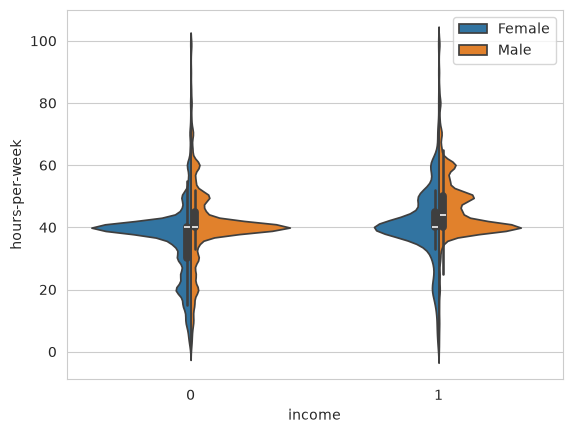

In [13]:
sns.violinplot(data=data, x = 'income', y = 'hours-per-week', hue = 'sex', split=True)
plt.legend(loc=0)

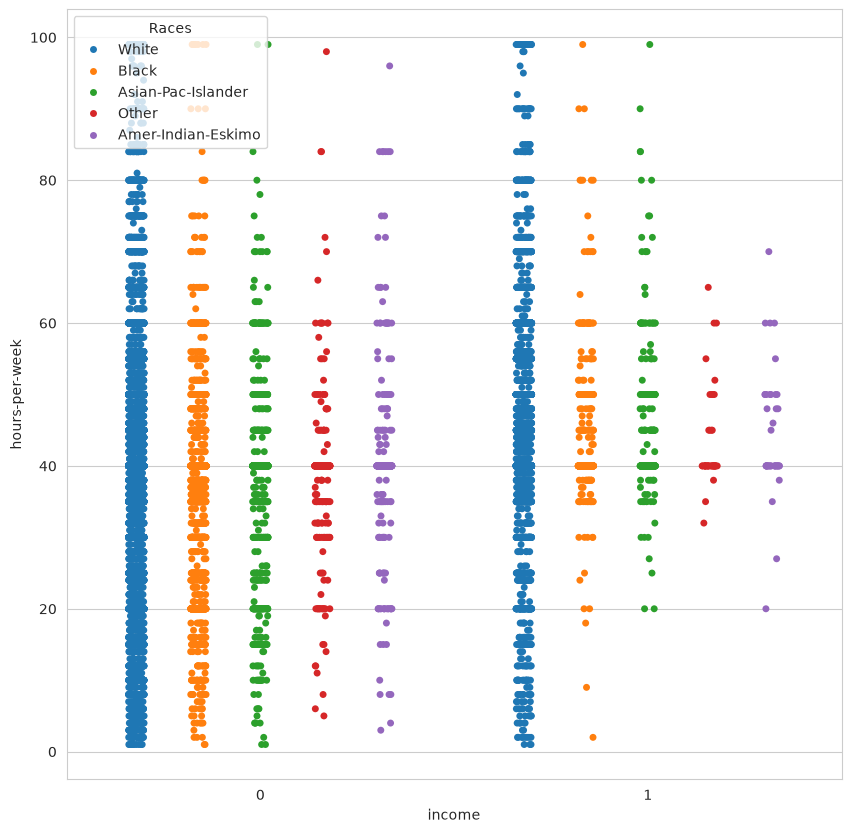

In [14]:
fig, ax = plt.subplots(figsize=(10,10))
sns.stripplot(ax=ax, data=data, x='income', y = 'hours-per-week', jitter=True, hue='race', dodge=True)
sns.move_legend(ax, loc='upper left', title='Races')

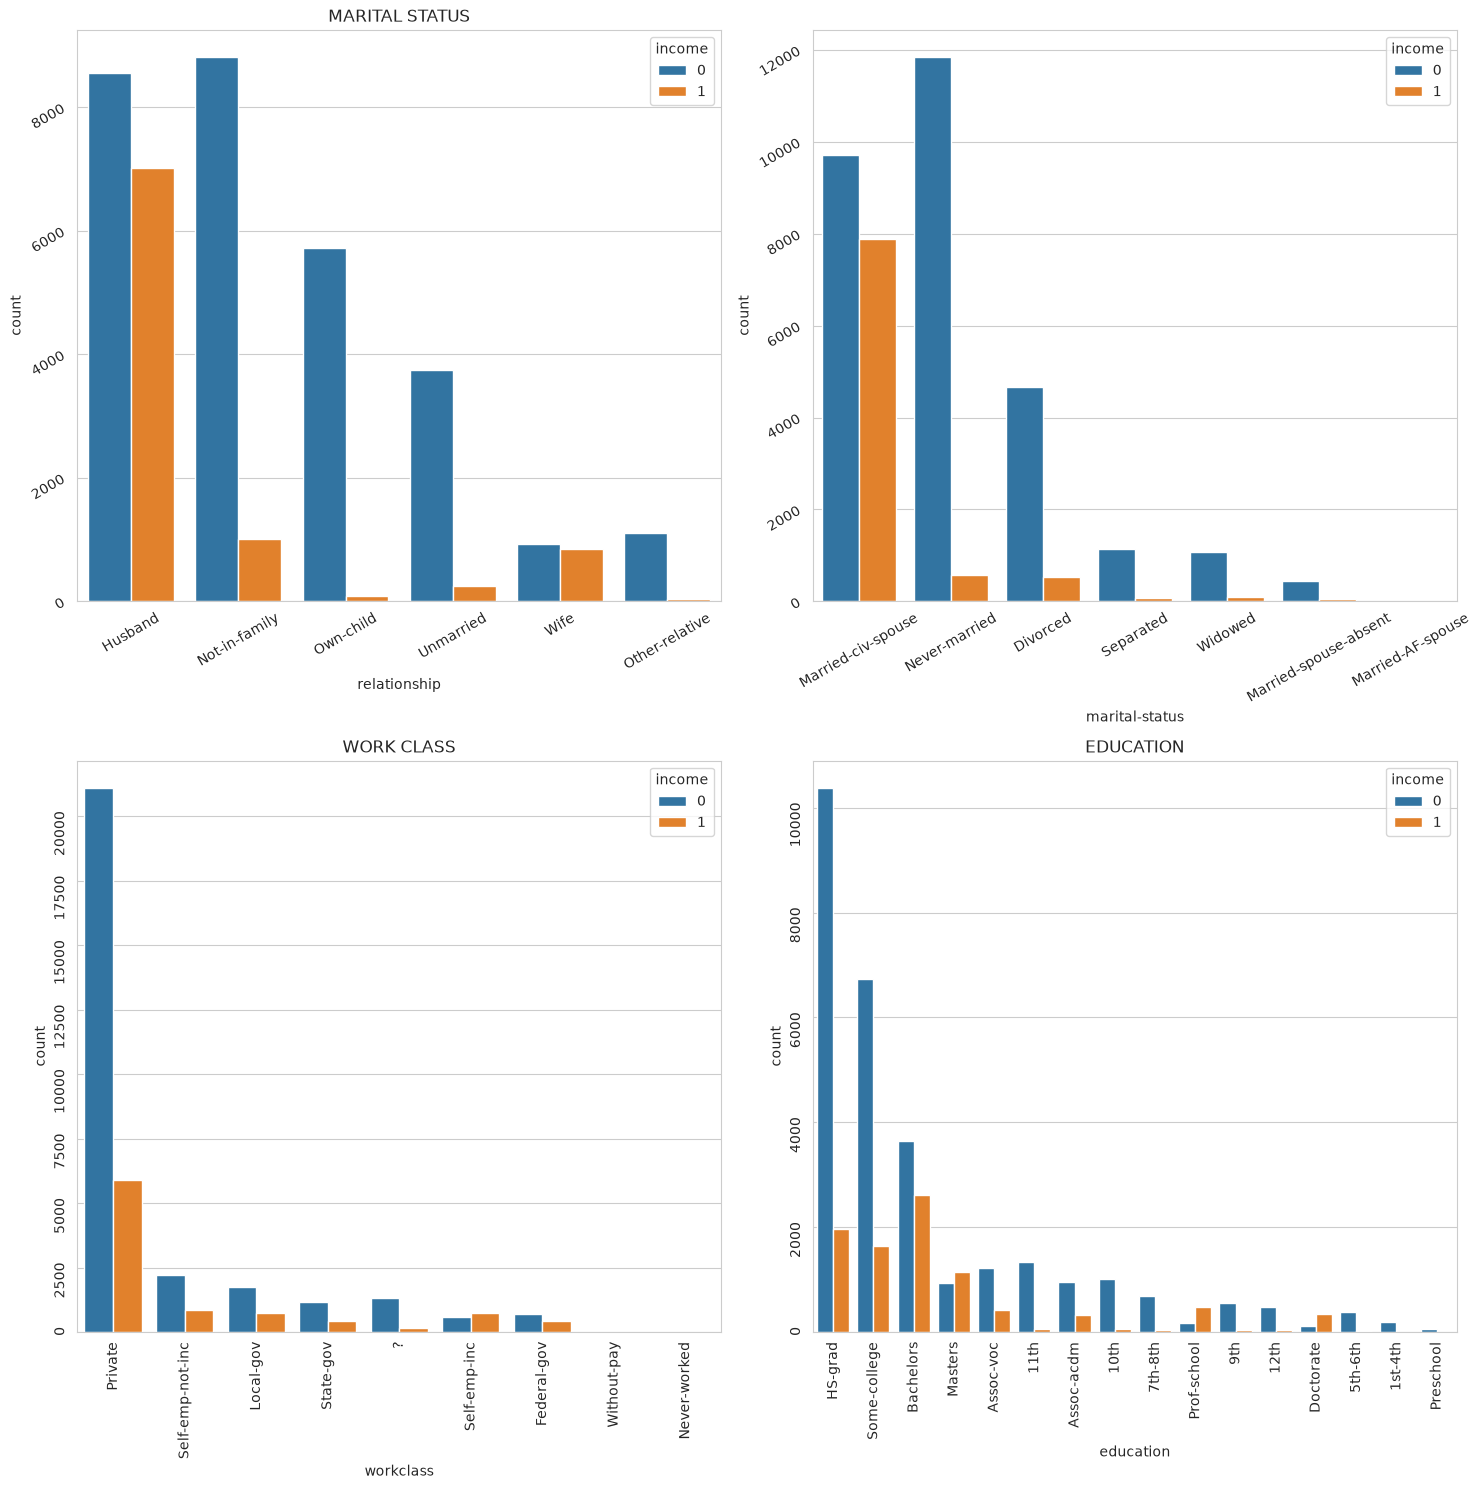

In [15]:
fig, ax = plt.subplots(2,2, figsize=(15,15))


order_r = data['relationship'].value_counts().index
sns.countplot(data=data, x='relationship', hue='income', order=order_r, ax=ax[0,0])
ax[0,0].tick_params(rotation=30)
ax[0,0].set_title('RELATIONSHIP')

order_ms = data['marital-status'].value_counts().index
sns.countplot(data=data, x='marital-status', hue='income', order=order_ms, ax=ax[0,1])
ax[0,1].tick_params(rotation=30)
ax[0,0].set_title('MARITAL STATUS')

order_wc = data['workclass'].value_counts().index
sns.countplot(data=data, x='workclass', hue='income', ax=ax[1,0], order=order_wc)
ax[1,0].tick_params(rotation=90)
ax[1,0].set_title('WORK CLASS')

order_ed = data['education'].value_counts().index
sns.countplot(data=data, x='education', hue='income', ax=ax[1,1], order=order_ed)
ax[1,1].tick_params(rotation=90)
ax[1,1].set_title('EDUCATION')

plt.tight_layout()

<Axes: ylabel='relationship'>

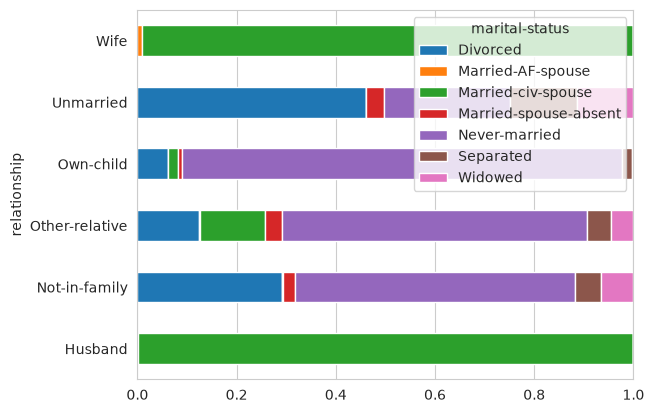

In [16]:
ct_rel_ms = pd.crosstab(data['relationship'], data['marital-status'], normalize='index')
ct_rel_ms.plot(kind='barh', stacked=True)

<Axes: ylabel='workclass'>

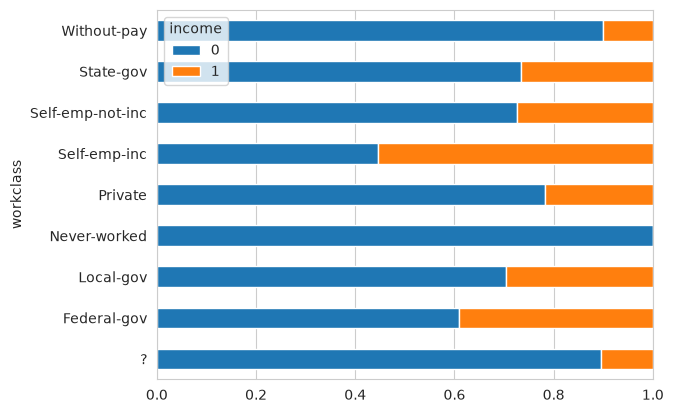

In [58]:
ct_wkc = pd.crosstab(data['workclass'], data['income'], normalize='index')
ct_wkc.plot(kind='barh', stacked=True)

<Axes: ylabel='education'>

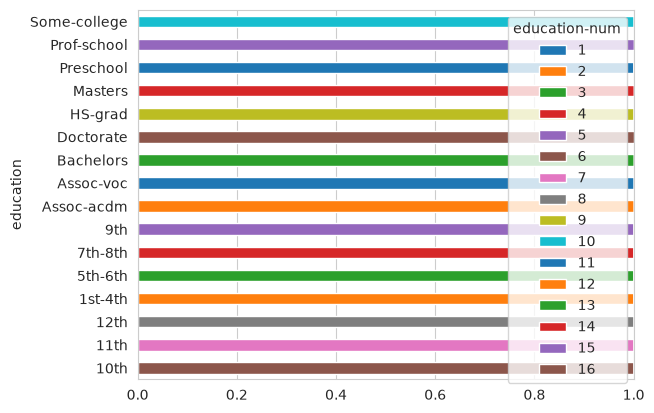

In [44]:
ct_edu = pd.crosstab(data['education'], data['education-num'], normalize='columns')
ct_edu.plot(kind='barh', stacked=True)

In [20]:
data['native-country'].value_counts()

native-country
United-States                 34369
Mexico                          749
?                               473
Philippines                     239
Germany                         158
Canada                          142
Puerto-Rico                     139
El-Salvador                     123
India                           114
Cuba                            111
South                            98
China                            97
England                          96
Italy                            87
Jamaica                          84
Dominican-Republic               79
Japan                            70
Guatemala                        69
Vietnam                          67
Poland                           67
Columbia                         64
Portugal                         57
Haiti                            55
Taiwan                           53
Iran                             45
Ecuador                          40
Greece                           37
Peru         

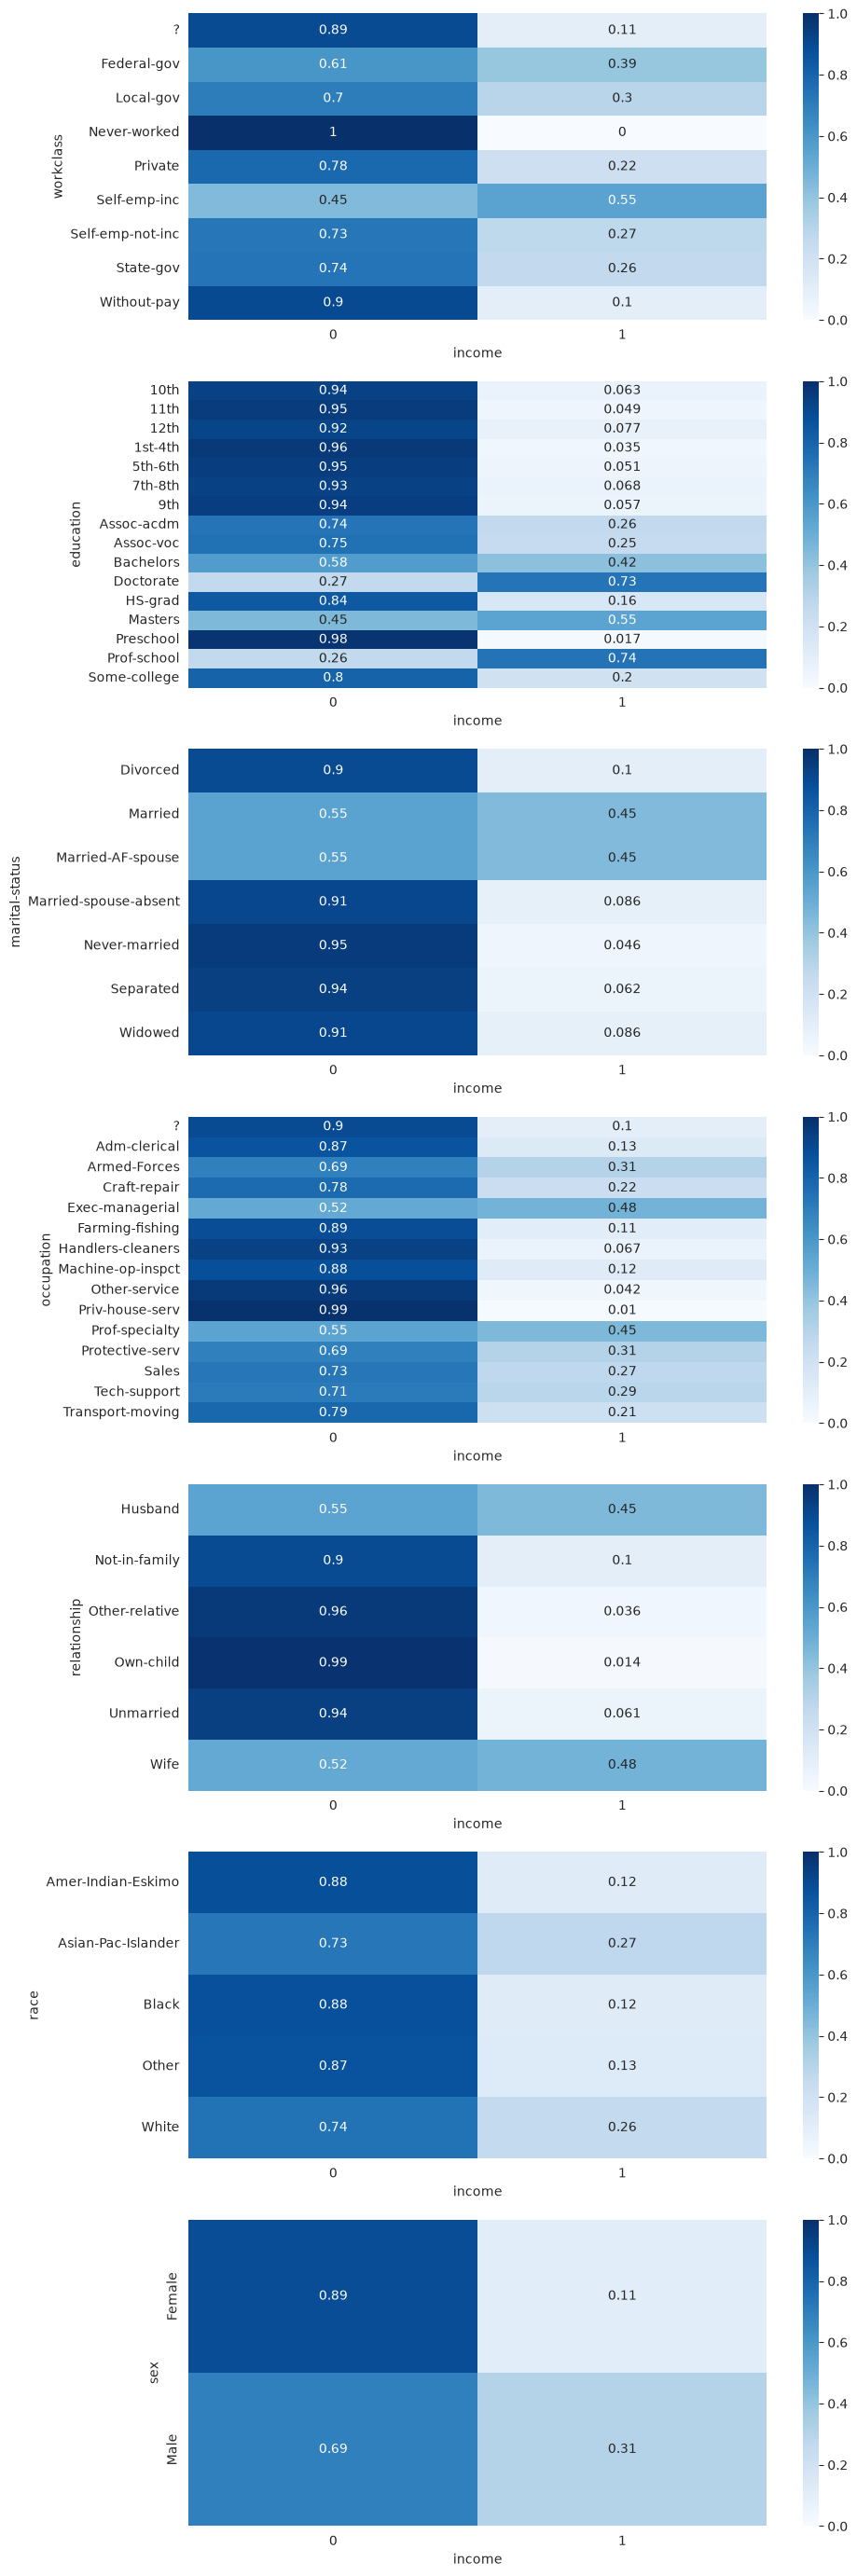

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = ['workclass', 'education', 'marital-status', 
        'occupation', 'relationship', 'race', 'sex']

fig, ax = plt.subplots(len(cols), 1, figsize = (10, 35))
i = 0
for i, col in enumerate(cols):
    ct = pd.crosstab(X_train[col], y_train, normalize='index')
    sns.heatmap(ct, annot=True, cmap='Blues', vmin=0, vmax=1, ax=ax[i])
plt.show()

# Models

### Pipeline

Feature engineering

In [36]:
from sklearn.base import BaseEstimator, TransformerMixin

class featureEngineer(BaseEstimator, TransformerMixin, threshold=20):
    def __init__(self):
        self.threshold = threshold
        
    def fit(self, X, y=None):
        X = X.copy()
        country_counter = X['native-country'].value_counts()
        self.rare_country_ = country_counter[country_counter < self.rare_].index
        return self

    def transform(self, X):
        X = X.copy()
        X.drop(columns='education')
        X['native-country'] = X['native-country'].mask(X['native_country'].isin(self.rare_country_), 'Other')
        X['capital'] = X['capital-gain'] - X['capital-loss']
        X.drop(columns=['capital-gain', 'capital-loss'], inplace=True)
        return X
        

/tmp/ipykernel_13083/1032694543.py:1: DeprecationWarning: Bitwise inversion '~' on bool is deprecated and will be removed in Python 3.16. This returns the bitwise inversion of the underlying int object and is usually not what you expect from negating a bool. Use the 'not' operator for boolean negation or ~int(x) if you really want the bitwise inversion of the underlying int.
  ~True


-2

Target encoder

In [22]:
class targetEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, cols, target_value):
        self.cols = cols
        self.target_value = target_value

    def fit(self, X, y):
        self.encodings_ = dict()
        for col in self.cols:
            encoding = (y == self.target_value).groupby(X[col]).mean()
            self.encodings_[col] = encoding
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.cols:
            X[col] = X[col].map(self.encodings_[col])
        return X

Pipeline

In [23]:
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


cols = ['workclass', 'marital-status', 
        'occupation', 'relationship', 'race', 'sex',
       'native-country']

pipe_tree = Pipeline(steps = [
    ('encoder', targetEncoder(cols = cols, target_value = 1)),
    ('tree', DecisionTreeClassifier())
])

pipe_rfc = Pipeline(steps = [
    ('encoder', targetEncoder(cols = cols, target_value = 1)),
    ('rfc', RandomForestClassifier())
])

pipe_xgbc = Pipeline(steps = [
    ('encoder', targetEncoder(cols = cols, target_value = 1)),
    ('xgbc', XGBClassifier())
])

### Decision Tree Classifier

In [24]:
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold

def objective(trial):

    params = {
        'tree__max_depth':trial.suggest_int('max_depth', 10, 100),
        'tree__min_samples_split':trial.suggest_int('min_samples_split', 2, 20),
        'tree__min_samples_leaf':trial.suggest_int('min_samples_leaf', 1, 10),
        'tree__max_leaf_nodes':trial.suggest_int('max_leaf_nodes', 20, 500),
        'tree__random_state':42}

    pipe_tree.set_params(**params)

    cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

    score = cross_val_score(estimator = pipe_tree,
                            X = X_train, 
                            y = y_train, 
                            cv=cv, scoring='f1_weighted').mean()

    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

print(f'BEST SCORE: {study.best_value}')
pipe_tree = pipe_tree.set_params(tree = DecisionTreeClassifier(**study.best_params))
pipe_tree.fit(X_train, y_train)    

[I 2026-07-20 13:12:25,566] A new study created in memory with name: no-name-ddbaad04-0422-426d-a573-f105688897e1
[I 2026-07-20 13:12:25,768] Trial 0 finished with value: 0.8444389356064121 and parameters: {'max_depth': 71, 'min_samples_split': 16, 'min_samples_leaf': 2, 'max_leaf_nodes': 21}. Best is trial 0 with value: 0.8444389356064121.
[I 2026-07-20 13:12:26,016] Trial 1 finished with value: 0.849545247412824 and parameters: {'max_depth': 55, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_leaf_nodes': 468}. Best is trial 1 with value: 0.849545247412824.
[I 2026-07-20 13:12:26,260] Trial 2 finished with value: 0.8500500642605398 and parameters: {'max_depth': 61, 'min_samples_split': 10, 'min_samples_leaf': 10, 'max_leaf_nodes': 334}. Best is trial 2 with value: 0.8500500642605398.
[I 2026-07-20 13:12:26,466] Trial 3 finished with value: 0.8518896900514852 and parameters: {'max_depth': 83, 'min_samples_split': 18, 'min_samples_leaf': 3, 'max_leaf_nodes': 52}. Best is trial 3 w

BEST SCORE: 0.8546397424918069


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('encoder', ...), ('tree', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
,cols,"['workclass', 'education', ...]"
,target_value,1
Name,Type,Value
encodings_,dict,"{'ed...on': education 10t...dtype: float64, 'ma...us': marital-statu...dtype: float64, 'na...ry': native-countr...dtype: float64, 'oc...on': occupation ? ...dtype: float64, ...}"
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",40


### Random Forest Classifier

In [25]:
from sklearn.ensemble import RandomForestClassifier

def objective(trial):
    params = {
        'rfc__n_estimators' : trial.suggest_int('n_estimators', 50, 500),
        'rfc__max_depth' : trial.suggest_int('max_depth', 5, 30),
        'rfc__min_samples_split': trial.suggest_int('min_samples_split', 2, 8),
        'rfc__min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 6),
    }
    
    pipe_rfc.set_params(**params)
    
    cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

    score = cross_val_score(estimator = pipe_rfc,
                            X = X_train, 
                            y = y_train, 
                            cv=cv, scoring='f1_weighted').mean()

    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=4)

print(f'BEST SCORE: {study.best_value}')
pipe_rfc = pipe_rfc.set_params(rfc = RandomForestClassifier(**study.best_params))
pipe_rfc.fit(X_train, y_train)

[I 2026-07-20 13:12:49,296] A new study created in memory with name: no-name-af665742-5d38-41d1-9bc0-7e34d72d1b98
[I 2026-07-20 13:12:50,889] Trial 0 finished with value: 0.8520684912045002 and parameters: {'n_estimators': 61, 'max_depth': 9, 'min_samples_split': 4, 'min_samples_leaf': 4}. Best is trial 0 with value: 0.8520684912045002.
[I 2026-07-20 13:13:04,881] Trial 1 finished with value: 0.8600767458408711 and parameters: {'n_estimators': 377, 'max_depth': 28, 'min_samples_split': 5, 'min_samples_leaf': 4}. Best is trial 1 with value: 0.8600767458408711.
[I 2026-07-20 13:13:07,795] Trial 2 finished with value: 0.8578478971716417 and parameters: {'n_estimators': 84, 'max_depth': 16, 'min_samples_split': 8, 'min_samples_leaf': 6}. Best is trial 1 with value: 0.8600767458408711.
[I 2026-07-20 13:13:22,140] Trial 3 finished with value: 0.8587709042200766 and parameters: {'n_estimators': 469, 'max_depth': 12, 'min_samples_split': 3, 'min_samples_leaf': 1}. Best is trial 1 with value: 0

BEST SCORE: 0.8600767458408711


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('encoder', ...), ('rfc', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
,cols,"['workclass', 'education', ...]"
,target_value,1
Name,Type,Value
encodings_,dict,"{'ed...on': education 10t...dtype: float64, 'ma...us': marital-statu...dtype: float64, 'na...ry': native-countr...dtype: float64, 'oc...on': occupation ? ...dtype: float64, ...}"
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",377


### XGBoost Classifier

In [26]:
def objective(trial):
    params = {
        'xgbc__n_estimators' : trial.suggest_int('n_estimators', 50, 500),
        'xgbc__max_depth' : trial.suggest_int('max_depth', 5, 12),
        'xgbc__learning_rate' : trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'xgbc__gamma' : trial.suggest_float('gamma', 0.01, 0.4),
        'xgbc__reg_lambda' : trial.suggest_float('reg_lambda', 1, 10, log=True),
        'xgbc__reg_alpha' : trial.suggest_float('reg_alpha', 0.001, 10, log=True),
        'xgbc__subsample': trial.suggest_float('subsample', 0.8, 1.0),
        'xgbc__colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1)}
    
    pipe_xgbc.set_params(**params)
        
    cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

    score = cross_val_score(estimator = pipe_xgbc,
                            X = X_train, 
                            y = y_train, 
                            cv=cv, scoring='f1_weighted').mean()

    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10)

print(f'BEST SCORE: {study.best_value}')
pipe_xgbc = pipe_xgbc.set_params(xgbc = XGBClassifier(**study.best_params))
pipe_xgbc.fit(X_train, y_train)

[I 2026-07-20 13:13:27,401] A new study created in memory with name: no-name-a205ae26-e077-478f-99e6-5b9e187d3356
[I 2026-07-20 13:13:28,950] Trial 0 finished with value: 0.8661976639973262 and parameters: {'n_estimators': 282, 'max_depth': 7, 'learning_rate': 0.0597811379989689, 'gamma': 0.2524370061597825, 'reg_lambda': 9.053683006838455, 'reg_alpha': 0.0028987888094963834, 'subsample': 0.8264240037376728, 'colsample_bytree': 0.6519870375892731}. Best is trial 0 with value: 0.8661976639973262.
[I 2026-07-20 13:13:29,394] Trial 1 finished with value: 0.8539077981900287 and parameters: {'n_estimators': 79, 'max_depth': 6, 'learning_rate': 0.02881038170645308, 'gamma': 0.08697799108228906, 'reg_lambda': 1.133616102037709, 'reg_alpha': 1.0979440987788522, 'subsample': 0.8885865720058213, 'colsample_bytree': 0.5679873328804322}. Best is trial 0 with value: 0.8661976639973262.
[I 2026-07-20 13:13:30,788] Trial 2 finished with value: 0.8627048132854257 and parameters: {'n_estimators': 422, 

BEST SCORE: 0.8662979319668069


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('encoder', ...), ('xgbc', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
,cols,"['workclass', 'education', ...]"
,target_value,1
Name,Type,Value
encodings_,dict,"{'ed...on': education 10t...dtype: float64, 'ma...us': marital-statu...dtype: float64, 'na...ry': native-countr...dtype: float64, 'oc...on': occupation ? ...dtype: float64, ...}"
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None


# Evalutaion

### Confusion Matrix

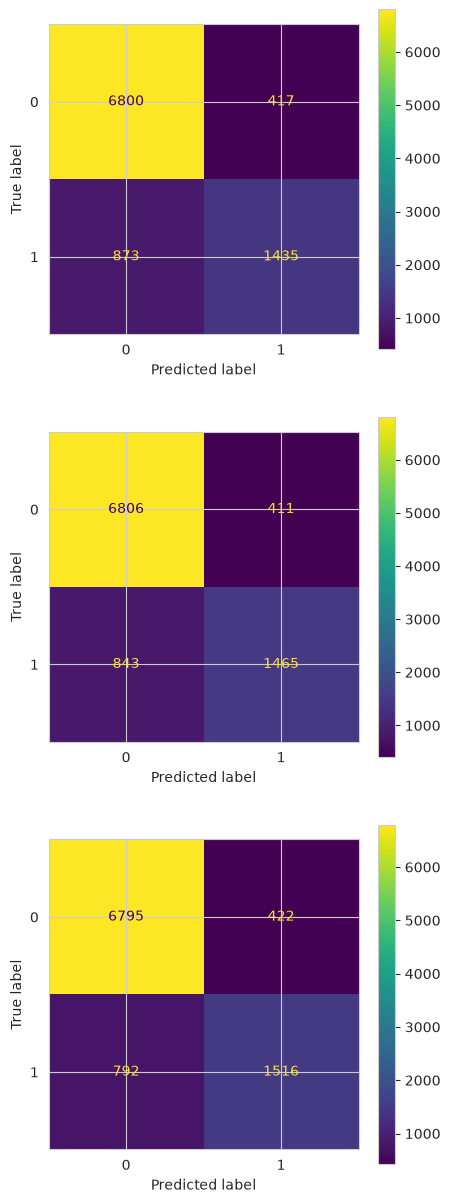

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, ax = plt.subplots(3, 1, figsize=(5, 15))

X_test['capital-total'] = X_test['capital-gain'] - X_test['capital-loss']

ConfusionMatrixDisplay.from_estimator(pipe_tree, X_test, y_test, ax=ax[0])
ConfusionMatrixDisplay.from_estimator(pipe_rfc, X_test, y_test, ax=ax[1])
ConfusionMatrixDisplay.from_estimator(pipe_xgbc, X_test, y_test, ax=ax[2])

### ROC Curve

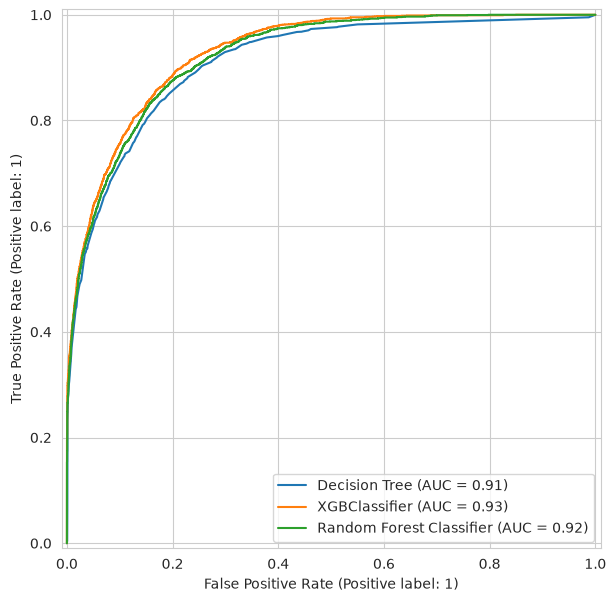

In [28]:
from sklearn.metrics import roc_curve
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize = (7,7))

RocCurveDisplay.from_estimator(pipe_tree, X_test, y_test, ax=ax, name='Decision Tree')
RocCurveDisplay.from_estimator(pipe_xgbc, X_test, y_test, ax=ax, name='XGBClassifier')
RocCurveDisplay.from_estimator(pipe_rfc, X_test, y_test, ax=ax, name='Random Forest Classifier')
plt.show()

### Metrics

In [29]:
from sklearn.metrics import accuracy_score, precision_score

names = {pipe_tree: 'Decision Tree Classifier',
             pipe_rfc: 'Random Forest Classifier', 
             pipe_xgbc: 'XGBoost Classifier'}

for model in (pipe_tree, pipe_rfc, pipe_xgbc):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    pre = precision_score(y_test, y_pred)
    print(names[model])
    print(f'Accuracy: {acc},\n Precision {pre}\n')

Decision Tree Classifier
Accuracy: 0.8645669291338582,
 Precision 0.7748380129589633

Random Forest Classifier
Accuracy: 0.8683464566929134,
 Precision 0.7809168443496801

XGBoost Classifier
Accuracy: 0.8725459317585302,
 Precision 0.782249742002064



# Saving models

In [31]:
import joblib

joblib.dump(pipe_tree, 'models/pipe_tree.joblib')
joblib.dump(pipe_rfc, 'models/pipe_rfc.joblib')
joblib.dump(pipe_xgbc, 'models/pipe_xgbc.joblib')


['models/pipe_xgbc.joblib']